# TP 4 - Finanzas Computacionales
Andres Polakoff, Baltazar Rojas Yenni, Simon Jaimovich y Uriel Corral Bianco

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros
r0 = 0.05
kappa = 0.03
theta = 0.04
sigma = 0.02
T = 1.0

def simulate(r0, kappa, theta, sigma, T, M, N):
    dt = T / M
    Z = np.random.randn(N, M)  # N trayectorias, M pasos
    r = np.zeros((N, M + 1))
    r[:, 0] = r0
    sqrt_dt = np.sqrt(dt)
    for k in range(M):
        r[:, k + 1] = r[:, k] + kappa * (theta - r[:, k]) * dt + sigma * sqrt_dt * Z[:, k]
    return r

def simulacion_vs_analitico(r0, kappa, theta, sigma, T, M, N):
    r = simulate(r0, kappa, theta, sigma, T, M, N)
    rT = r[:, -1]
    mu_simulado = np.mean(rT)
    sigma2_simulado = np.var(rT, ddof=1)
    mu_analitico = theta + (r0 - theta) * np.exp(-kappa*T)
    sigma2_analitico = (sigma**2 / (2*kappa)) * (1 - np.exp(-2*kappa*T))
    return rT, mu_simulado,  mu_analitico, sigma2_simulado, sigma2_analitico

Media simulación: 0.04965652298110318
Media exacta: 0.049704455335485086
Varianza simulación: 0.00038727449364205264
Varianza analítica: 0.0003882364427716752


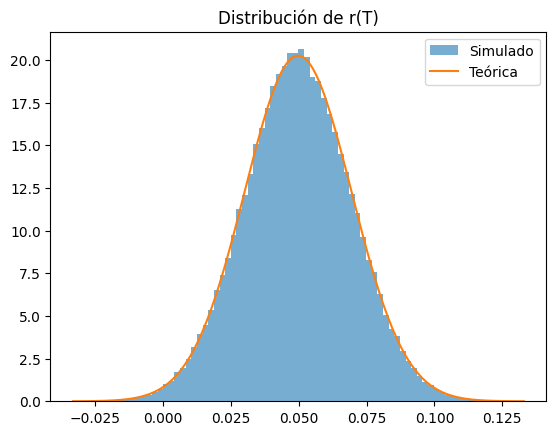

In [ ]:
M = 500
N = 100000

rT, mu_simulado, mu_analitico, sigma2_simulado, sigma2_analitico = simulacion_vs_analitico(r0, kappa, theta, sigma, T, M, N)

print("Media simulación:", mu_simulado)
print("Media exacta:", mu_analitico)
print("Varianza simulación:", sigma2_simulado)
print("Varianza analítica:", sigma2_analitico)

plt.hist(rT, bins=80, density=True, alpha=0.6, label="Simulado")
''' Histograma que contiene a todos los rT obtenidos en cada una de las
N iteraciones, 80 es el número de barras'''

# Densidad normal teórica
x = np.linspace(min(rT), max(rT), 200)
'''Creamos una serie de puntos entre el rT min y max para
posteriormente plotear una normal con el mu y sigma analíticos y comparar con el histograma'''

plt.plot(x, norm.pdf(x, mu_analitico, np.sqrt(sigma2_analitico)), label="Teórica") # Ploteamos la normal

plt.title("Distribución de r(T)")
plt.legend()
plt.show()


In [ ]:
def simulate_forward(r0, kappa, theta, sigma, T, M, K, N):
    dt = T / M
    Z = np.random.randn(N, M)  # Simulación de ruido normal estándar (N x M)
    r = np.zeros((N, M+1))
    r[:, 0] = r0
    sqrt_dt = np.sqrt(dt)
    for k in range(M):
        r[:, k+1] = r[:, k] + kappa * (theta - r[:, k]) * dt + sigma * sqrt_dt * Z[:, k]
    DT = np.exp(-np.sum(r[:, :-1] * dt, axis=1))
    payoff = DT * (r[:, -1] - K)
    return payoff

def precio_forward(r0, kappa, theta, sigma, T, M, K, N):
    payoffs = simulate_forward(r0, kappa, theta, sigma, T, M, K, N)
    precio = np.mean(payoffs)
    varianza = np.var(payoffs, ddof=1)
    return precio, varianza

In [ ]:
K = 0.04
M = 500

Ns = [100, 500, 1000, 5000, 10000, 50000, 100000]

resultados = []

for N in Ns:
    precio, varianza = precio_forward(r0, kappa, theta, sigma, T, M, K, N)
    resultados.append([N, precio, varianza])
    print(f"N={N}, Precio={precio:.6f}, Var={varianza:.6f}")


N=100, Precio=0.010166, Var=0.000360
N=500, Precio=0.008941, Var=0.000325
N=1000, Precio=0.009994, Var=0.000336
N=5000, Precio=0.008567, Var=0.000364
N=10000, Precio=0.009107, Var=0.000357
N=50000, Precio=0.008998, Var=0.000349
N=100000, Precio=0.009106, Var=0.000348


1. Obtuvimos los siguientes precios:

N=100, Precio=0.010185

N=500, Precio=0.009464

N=1000, Precio=0.009245

N=5000, Precio=0.009413

N=10000, Precio=0.009027

N=50000, Precio=0.009020

N=100000, Precio=0.009049

2. Buscamos la varianza del estimador:
$$
\operatorname{Var}\!\left(\hat V_0^{(MC)}\right)
=
\operatorname{Var}\!\left(\frac{1}{N}\sum_{i=1}^N Payoff_i\right)
=
\frac{1}{N^2}\,\operatorname{Var}\!\left(\sum_{i=1}^N Payoff_i\right).
$$

Como los $X_i$ son independientes:

$$
\operatorname{Var}\!\left(\sum_{i=1}^N Payoff_i\right)
=
\sum_{i=1}^N \operatorname{Var}(Payoff_i)
=
N\,\operatorname{Var}(Payoff).
$$

Por lo tanto,

$$
\operatorname{Var}\!\left(\hat V_0^{(MC)}\right)
=
\frac{1}{N^2} N\,\operatorname{Var}(Payoff)
=
\frac{\operatorname{Var}(Payoff)}{N}.
$$


De esta forma, determinamos la varianza para el estimador de cada uno de los N:

N=100, Varianza= 0,00000425

N=500, Varianza= 0,000018928

N=1000, Varianza= 0,000000357

N=5000, Varianza= 0,0000000692

N=10000, Varianza= 0,0000000352

N=50000, Varianza= 0,00000000698

N=100000, Varianza= 0,00000000348



3. Estimamos el error relativo de cada una de las simulaciones con distintos N contra la de un N gigante.

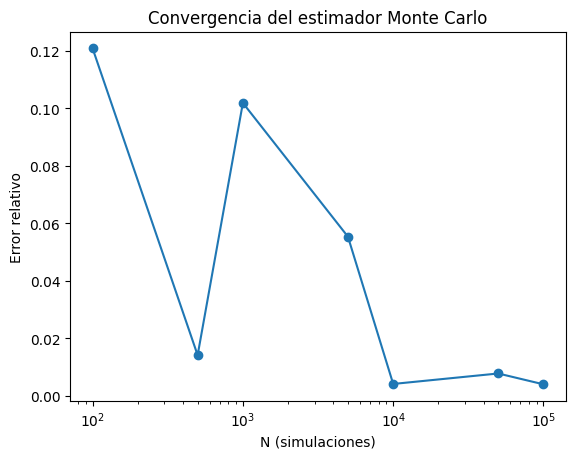

0.009069287963973216


In [ ]:
N_ref = 950000
precio_ref, _ = precio_forward(r0, kappa, theta, sigma, T, M, K, N_ref)

resultados_np = np.array(resultados)
precios_simulados = resultados_np[:, 1]
errores = np.abs(precios_simulados - precio_ref) / np.abs(precio_ref)

plt.plot(Ns, errores, marker="o")
#plt.xscale("log")  # escala logarítmica para ver mejor la convergencia
plt.xlabel("N (simulaciones)")
plt.ylabel("Error relativo")
plt.title("Convergencia del estimador Monte Carlo")
plt.xscale("log")
plt.show()
print(precio_ref)

Como se puede observar en el grafico, vemos como a medida que aumentan la cantidad de iteraciones, el error va convergiendo a cero.